In [1]:
# pip install xarray netCDF4 pandas numpy scikit-learn xgboost joblib

import numpy as np
import pandas as pd
import xarray as xr
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import joblib

In [2]:
import glob
import xarray as xr

PATH = "/Users/lb962/Documents/GitHub/ESL_stats/data/ml4_removed/*"

# Get sorted list of files
files = sorted(glob.glob(PATH))

# Open each file into a list of datasets
datasets = [xr.open_dataset(f) for f in files]

# Example: inspect or process one
for i, ds in enumerate(datasets):
    print(f"File {i}: {files[i]}")
    print(ds)

# If you want them in memory:
datasets = [ds.load() for ds in datasets]

File 0: /Users/lb962/Documents/GitHub/ESL_stats/data/ml4_removed/station_1.nc
<xarray.Dataset> Size: 58MB
Dimensions:              (valid_time: 750192)
Coordinates:
    station              int64 8B ...
  * valid_time           (valid_time) datetime64[ns] 6MB 1940-01-01 ... 2025-...
    latitude             float64 8B ...
    longitude            float64 8B ...
    station_latitude     float64 8B ...
    station_longitude    float64 8B ...
    year                 (valid_time) int64 6MB ...
Data variables: (12/15)
    u10                  (valid_time) float32 3MB ...
    v10                  (valid_time) float32 3MB ...
    d2m                  (valid_time) float32 3MB ...
    t2m                  (valid_time) float32 3MB ...
    msl                  (valid_time) float32 3MB ...
    sst                  (valid_time) float32 3MB ...
    ...                   ...
    mwp                  (valid_time) float32 3MB ...
    swh                  (valid_time) float32 3MB ...
    sea_level     

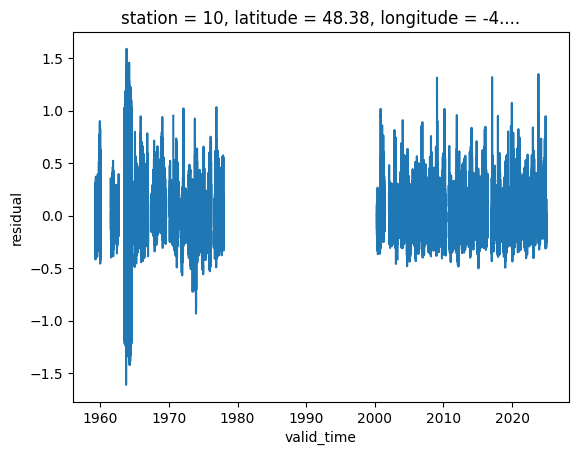

In [3]:
da = datasets[1].residual
da.plot()

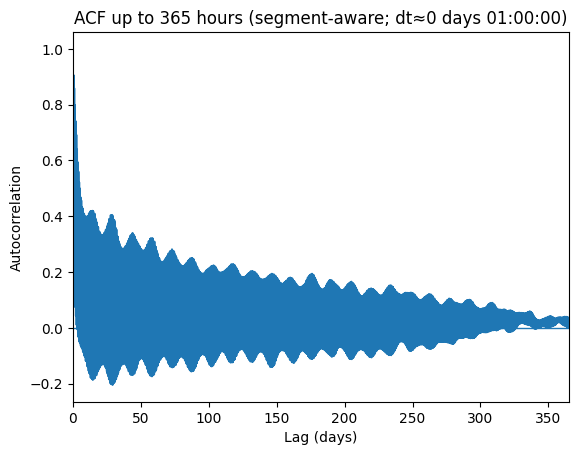

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf

def plot_acf_upto_365d(da, time_name="valid_time", max_days=365, gap_factor=5,
                      fill_small_gaps=True, small_gap_max_steps=3, fft=True):
    """
    da: 1D xr.DataArray with a datetime coordinate (time_name)
    gap_factor: split segments when dt > gap_factor * median_dt
    fill_small_gaps: interpolate small NaN runs within segments only
    small_gap_max_steps: max consecutive NaN steps to fill within a segment
    """

    # Convert to pandas Series for convenience
    s = da.to_series()
    s = s.sort_index()

    # Estimate nominal sampling interval
    dt = s.index.to_series().diff().median()
    if pd.isna(dt) or dt <= pd.Timedelta(0):
        raise ValueError("Could not infer a valid sampling interval from the time coordinate.")
    max_lag = int(pd.Timedelta(days=max_days) / dt)

    # Identify big gaps and split into segments
    gap = s.index.to_series().diff() > (gap_factor * dt)
    seg_id = gap.cumsum()

    acfs = []
    weights = []

    for _, seg in s.groupby(seg_id):
        # Drop leading/trailing NaNs
        seg = seg.dropna(how="all")
        if len(seg) < (max_lag + 2):
            continue

        # Handle NaNs inside the segment
        if seg.isna().any():
            if fill_small_gaps:
                # Only fill small NaN runs; leave longer missing stretches as NaN
                is_nan = seg.isna().to_numpy()
                if is_nan.any():
                    # find run lengths of NaNs
                    nan_runs = []
                    start = None
                    for i, v in enumerate(is_nan):
                        if v and start is None:
                            start = i
                        if not v and start is not None:
                            nan_runs.append((start, i-1))
                            start = None
                    if start is not None:
                        nan_runs.append((start, len(is_nan)-1))

                    seg_vals = seg.to_numpy().copy()
                    for a, b in nan_runs:
                        run_len = b - a + 1
                        if run_len <= small_gap_max_steps:
                            # interpolate only this short run
                            x = np.arange(len(seg_vals))
                            good = ~np.isnan(seg_vals)
                            seg_vals[a:b+1] = np.interp(x[a:b+1], x[good], seg_vals[good])
                    seg = pd.Series(seg_vals, index=seg.index)
            # After optional small-gap fill, drop remaining NaNs (prevents artifacts)
            seg = seg.dropna()

        if len(seg) < (max_lag + 2):
            continue

        y = seg.to_numpy()
        y = y - np.mean(y)

        # Efficient ACF computation
        a = acf(y, nlags=max_lag, fft=fft)
        acfs.append(a)
        weights.append(len(y))  # weight by segment length

    if not acfs:
        raise ValueError("No segment long enough to compute ACF up to 365 days after NaN/gap handling.")

    # Weighted average across segments (optional but usually sensible)
    A = np.vstack(acfs)
    w = np.asarray(weights, float)
    acf_mean = np.average(A, axis=0, weights=w)

    lags = np.arange(len(acf_mean))
    lags_days = (lags * dt) / pd.Timedelta(days=1)

    plt.figure()
    plt.plot(lags_days, acf_mean)
    plt.xlabel("Lag (days)")
    plt.ylabel("Autocorrelation")
    plt.title(f"ACF up to {max_days} hours (segment-aware; dt≈{dt})")
    plt.xlim(0, max_days)
    plt.axhline(0, linewidth=1)
    plt.show()

    return lags_days, acf_mean, dt, seg
lags_days, acf_mean, dt, seg = plot_acf_upto_365d(da, time_name="valid_time", max_days=365, gap_factor=5,
                      fill_small_gaps=True, small_gap_max_steps=3, fft=True)

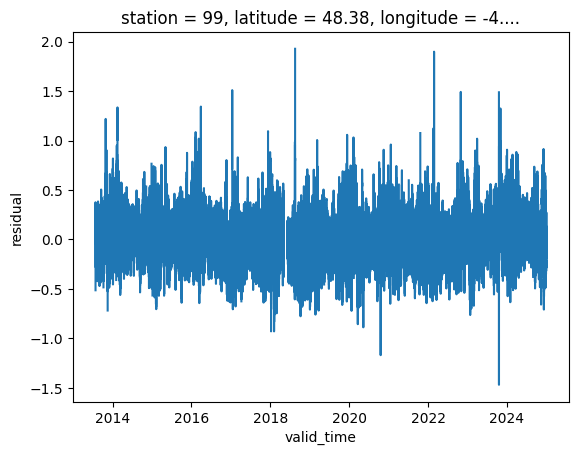

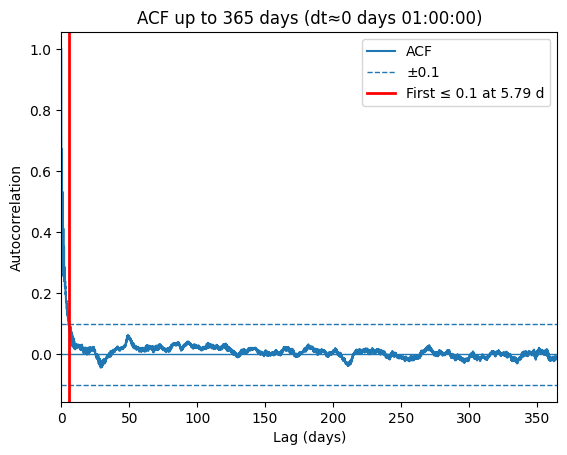

First lag where |ACF| ≤ 0.1 (sustained for 24h): 5.79 days


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf

def plot_acf_upto_365d_with_threshold(
    da, time_name="valid_time", max_days=365, gap_factor=5,
    fill_small_gaps=True, small_gap_max_steps=3, fft=True,
    threshold=0.15, sustain_hours=24, plot=True
):
    # Convert to pandas Series (datetime index)
    s = da.to_series().sort_index()

    # Nominal sampling interval (e.g., 1 hour)
    dt = s.index.to_series().diff().median()
    if pd.isna(dt) or dt <= pd.Timedelta(0):
        raise ValueError("Could not infer a valid sampling interval from the time coordinate.")

    max_lag = int(pd.Timedelta(days=max_days) / dt)

    # Split on big gaps (do NOT interpolate across massive gaps)
    gap = s.index.to_series().diff() > (gap_factor * dt)
    seg_id = gap.cumsum()

    acfs, weights = [], []

    for _, seg in s.groupby(seg_id):
        seg = seg.dropna(how="all")
        if len(seg) < (max_lag + 2):
            continue

        # Fill only small NaN runs, then drop remaining NaNs
        if seg.isna().any():
            if fill_small_gaps:
                is_nan = seg.isna().to_numpy()
                nan_runs, start = [], None
                for i, v in enumerate(is_nan):
                    if v and start is None:
                        start = i
                    if not v and start is not None:
                        nan_runs.append((start, i - 1))
                        start = None
                if start is not None:
                    nan_runs.append((start, len(is_nan) - 1))

                seg_vals = seg.to_numpy().copy()
                x = np.arange(len(seg_vals))
                good = ~np.isnan(seg_vals)
                for a, b in nan_runs:
                    if (b - a + 1) <= small_gap_max_steps and good.any():
                        seg_vals[a:b+1] = np.interp(x[a:b+1], x[good], seg_vals[good])
                seg = pd.Series(seg_vals, index=seg.index)

            seg = seg.dropna()

        if len(seg) < (max_lag + 2):
            continue

        y = seg.to_numpy()
        y = y - np.mean(y)

        a = acf(y, nlags=max_lag, fft=fft)
        acfs.append(a)
        weights.append(len(y))

    if not acfs:
        raise ValueError("No segment long enough to compute ACF up to 365 days after NaN/gap handling.")

    # Weighted average ACF across segments
    A = np.vstack(acfs)
    w = np.asarray(weights, float)
    acf_mean = np.average(A, axis=0, weights=w)

    lags = np.arange(len(acf_mean))
    lags_days = (lags * dt) / pd.Timedelta(days=1)

    # Find first lag where |ACF| <= threshold for sustain_hours consecutively
    sustain = max(1, int(pd.Timedelta(hours=sustain_hours) / dt))
    tau_days = np.nan
    for i in range(len(acf_mean) - sustain):
        if np.all(np.abs(acf_mean[i:i+sustain]) <= threshold):
            tau_days = float(lags_days[i])
            break

    # Plot
    if plot == True:
        plt.figure()
        plt.plot(lags_days, acf_mean, label="ACF")
        plt.axhline(0, linewidth=1)
        plt.axhline(threshold, linestyle="--", linewidth=1, label=f"±{threshold}")
        plt.axhline(-threshold, linestyle="--", linewidth=1)

        if np.isfinite(tau_days):
            plt.axvline(tau_days, color="red", linewidth=2, label=f"First ≤ {threshold} at {tau_days:.2f} d")

        plt.xlabel("Lag (days)")
        plt.ylabel("Autocorrelation")
        plt.title(f"ACF up to {max_days} days (dt≈{dt})")
        plt.xlim(0, max_days)
        plt.legend()
        plt.show()

        if np.isfinite(tau_days):
            print(f"First lag where |ACF| ≤ {threshold} (sustained for {sustain_hours}h): {tau_days:.2f} days")
        else:
            print(f"ACF does not drop below |{threshold}| (sustained for {sustain_hours}h) within {max_days} days.")

    return lags_days, acf_mean, dt, tau_days

nr = 30
datasets[i].residual.plot()
# Usage
lags_days, acf_mean, dt, tau_days = plot_acf_upto_365d_with_threshold(
    datasets[i].residual,
    time_name="valid_time",
    max_days=365,
    gap_factor=5,
    fill_small_gaps=True,
    small_gap_max_steps=3,
    fft=True,
    threshold=0.1,
    sustain_hours=24
)


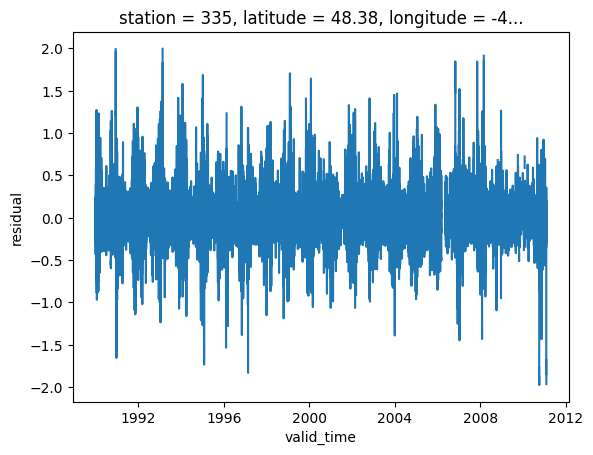

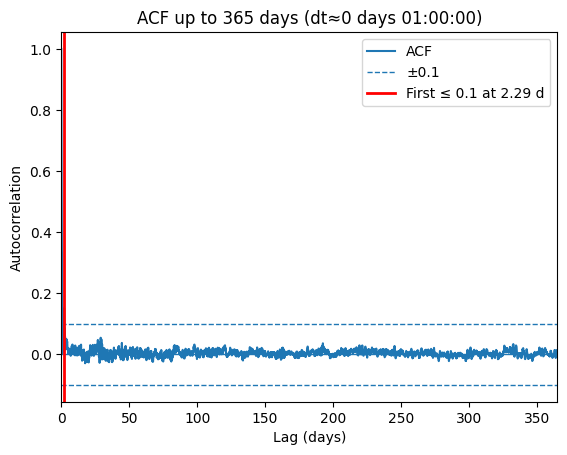

First lag where |ACF| ≤ 0.1 (sustained for 24h): 2.29 days


In [6]:
i= 121
datasets[i].residual.plot()
# Usage
lags_days, acf_mean, dt, tau_days = plot_acf_upto_365d_with_threshold(
    datasets[i].residual,
    time_name="valid_time",
    max_days=365,
    gap_factor=5,
    fill_small_gaps=True,
    small_gap_max_steps=3,
    fft=True,
    threshold=0.1,
    sustain_hours=24
)

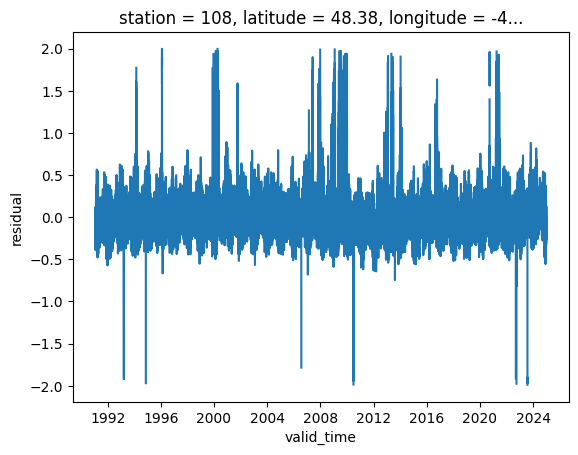

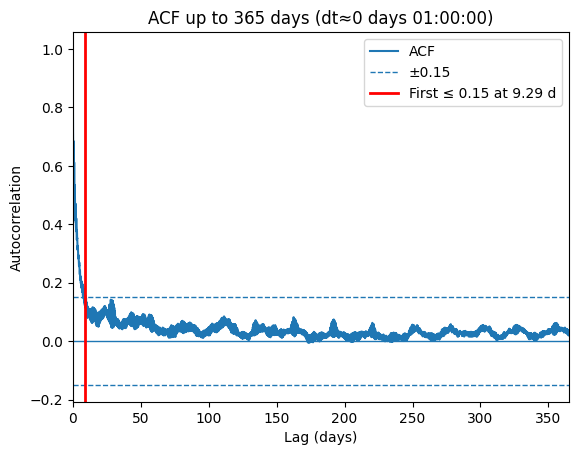

First lag where |ACF| ≤ 0.15 (sustained for 24h): 9.29 days


In [7]:
i= 5
datasets[i].residual.plot()
# Usage
lags_days, acf_mean, dt, tau_days = plot_acf_upto_365d_with_threshold(
    datasets[i].residual,
    time_name="valid_time",
    max_days=365,
    gap_factor=5,
    fill_small_gaps=True,
    small_gap_max_steps=3,
    fft=True,
    threshold=0.15,
    sustain_hours=24
)

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _first_present(d, keys):
    for k in keys:
        if k in d:
            return k
    return None

def extract_lat_lon_station(ds, fallback_station=None):
    """
    Attempts to extract (station_id, lat, lon) from ds.
    Works if lat/lon are in coords, data_vars, or attrs.
    """
    # Station id: prefer attrs if present, else fallback index
    station_id = (
        ds.attrs.get("station")
        or ds.attrs.get("station_id")
        or ds.attrs.get("id")
        or ds.attrs.get("name")
        or fallback_station
    )

    # Candidate names
    lat_keys = ["station_latitude", "lat", "Latitude", "LAT"]
    lon_keys = ["station_longitude", "lon", "Longitude", "LON"]

    # 1) coords
    lat_k = _first_present(ds.coords, lat_keys)
    lon_k = _first_present(ds.coords, lon_keys)

    lat = ds.coords[lat_k].values if lat_k else None
    lon = ds.coords[lon_k].values if lon_k else None

    # 2) data_vars (sometimes stored as variables)
    if lat is None:
        lat_k = _first_present(ds.data_vars, lat_keys)
        if lat_k:
            lat = ds[lat_k].values
    if lon is None:
        lon_k = _first_present(ds.data_vars, lon_keys)
        if lon_k:
            lon = ds[lon_k].values

    # 3) attrs
    if lat is None:
        for k in lat_keys:
            if k in ds.attrs:
                lat = ds.attrs[k]
                break
    if lon is None:
        for k in lon_keys:
            if k in ds.attrs:
                lon = ds.attrs[k]
                break

    # Convert to scalars if arrays
    def to_scalar(x):
        if x is None:
            return np.nan
        x = np.asarray(x)
        return float(x.ravel()[0]) if x.size else np.nan

    return station_id, to_scalar(lat), to_scalar(lon)
results = []

for idx, ds in enumerate(datasets):
    try:
        # pull location metadata
        station_id, lat, lon = extract_lat_lon_station(ds, fallback_station=idx)

        # compute tau (first sustained lag <= 0.1) on residual
        _, _, _, tau_days = plot_acf_upto_365d_with_threshold(
            ds["residual"],
            time_name="valid_time",
            max_days=365,
            gap_factor=5,
            fill_small_gaps=True,
            small_gap_max_steps=3,
            fft=True,
            threshold=0.15,
            sustain_hours=24,
            plot=False
        )

        results.append(
            {
                "station": station_id,
                "idx": idx,
                "lat": lat,
                "lon": lon,
                "decorrelation_days": tau_days,
            }
        )

    except Exception as e:
        # keep a record of failures rather than crashing the loop
        station_id, lat, lon = extract_lat_lon_station(ds, fallback_station=idx)
        results.append(
            {
                "station": station_id,
                "idx": idx,
                "lat": lat,
                "lon": lon,
                "decorrelation_days": np.nan,
                "error": str(e),
            }
        )

df = pd.DataFrame(results)
df

,station,idx,lat,lon,decorrelation_days,error
0,0,0,48.383000,-4.495000,9.833333,NaN
1,1,1,45.568480,-1.061555,165.208333,NaN
2,2,2,50.102000,-5.542000,9.791667,NaN
3,3,3,50.103000,-5.542750,75.125000,NaN
4,4,4,50.099998,-5.533330,16.666667,NaN
...,...,...,...,...,...,...
290,290,290,49.481602,0.105600,6.333333,NaN
291,291,291,49.651299,-1.635500,7.750000,NaN
292,292,292,49.431831,0.110670,NaN,No segment long enough to compute ACF up to 36...
293,293,293,49.183300,-2.116700,8.750000,NaN


In [77]:
datasets.shape()

AttributeError: 'list' object has no attribute 'shape'

In [111]:
import numpy as np
import pandas as pd
def dataset_length_years(ds, var="residual", time_name="valid_time"):
    """
    Effective record length based only on timestamps where data is NOT NaN.
    Returns (years, n_valid, tmin, tmax)
    """

    # Ensure variable exists
    if var not in ds:
        return np.nan, 0, pd.NaT, pd.NaT

    # Get time coordinate
    if (time_name not in ds) and (time_name not in ds.coords):
        return np.nan, 0, pd.NaT, pd.NaT

    t = ds[time_name].values if time_name in ds else ds.coords[time_name].values
    y = ds[var].values

    # Convert time to datetime safely
    t = pd.to_datetime(t, errors="coerce")

    # Build mask of VALID data points
    valid_mask = (~pd.isna(t)) & (~np.isnan(y))

    if valid_mask.sum() == 0:
        return np.nan, 0, pd.NaT, pd.NaT

    t_valid = t[valid_mask]

    tmin = t_valid.min()
    tmax = t_valid.max()
    n_valid = len(t_valid)

    dt_days = (tmax - tmin) / np.timedelta64(1, "D")
    years = float(dt_days) / 365.25

    return years, n_valid, tmin, tmax

    return years, n, tmin, tmax
def get_station_id(ds, fallback):
    # prefer explicit metadata; fallback to index
    sid = (
        ds.attrs.get("station")
        or ds.attrs.get("station_id")
        or ds.attrs.get("id")
        or ds.attrs.get("name")
    )
    if sid is None or str(sid).strip() == "":
        sid = fallback
    return str(sid)

meta_rows = []

for idx, ds in enumerate(datasets):
    row = {"idx": idx}

    # sanity checks: is it an xarray Dataset-like object?
    if not hasattr(ds, "attrs") or not hasattr(ds, "coords"):
        row.update({"station": str(idx), "is_dataset": False, "years": np.nan, "n_obs": np.nan,
                    "tmin": pd.NaT, "tmax": pd.NaT, "meta_error": "Not an xarray Dataset"})
        meta_rows.append(row)
        continue

    row["is_dataset"] = True
    row["station"] = get_station_id(ds, fallback=idx)

    years, nobs, tmin, tmax = dataset_length_years(ds, time_name="valid_time")
    row.update({"years": years, "n_obs": nobs, "tmin": tmin, "tmax": tmax, "meta_error": ""})

    meta_rows.append(row)

meta_df = pd.DataFrame(meta_rows)
length_rows = []

for idx, ds in enumerate(datasets):
    yrs, nobs, tmin, tmax = dataset_length_years(ds, time_name="valid_time")
    length_rows.append({"idx": idx, "years": yrs, "n_obs": nobs, "tmin": tmin, "tmax": tmax})

len_df = pd.DataFrame(length_rows)

df2 = df.merge(len_df, on="idx", how="left")

In [112]:
df2

,station,idx,lat,lon,decorrelation_days,error,years,n_obs,tmin,tmax
0,0,0,48.383000,-4.495000,9.833333,NaN,66.254962,577480,1952-09-29 08:00:00,2018-12-31 23:00:00
1,1,1,45.568480,-1.061555,165.208333,NaN,65.705681,315236,1959-04-18 23:00:00,2024-12-31 23:00:00
2,2,2,50.102000,-5.542000,9.791667,NaN,63.915013,541411,1950-01-01 00:00:00,2013-11-30 23:00:00
3,3,3,50.103000,-5.542750,75.125000,NaN,75.000570,639894,1950-01-01 00:00:00,2024-12-31 23:00:00
4,4,4,50.099998,-5.533330,16.666667,NaN,35.000342,287720,1990-01-01 02:00:00,2024-12-31 23:00:00
...,...,...,...,...,...,...,...,...,...,...
290,290,290,49.481602,0.105600,6.333333,NaN,71.361282,461354,1953-08-21 23:00:00,2024-12-31 16:00:00
291,291,291,49.651299,-1.635500,7.750000,NaN,61.997718,432842,1963-01-01 23:00:00,2024-12-31 15:00:00
292,292,292,49.431831,0.110670,NaN,No segment long enough to compute ACF up to 36...,NaN,0,NaT,NaT
293,293,293,49.183300,-2.116700,8.750000,NaN,32.096053,271558,1992-11-26 21:00:00,2024-12-31 23:00:00


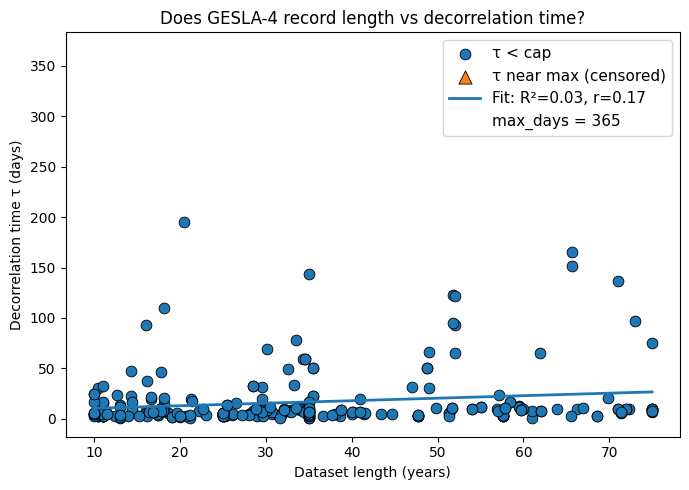

In [121]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Prepare plotting dataframe
# ----------------------------
plot_df = df2.dropna(subset=["decorrelation_days", "years"]).copy()

MAX_DAYS = 365
CAP_THRESHOLD = 0.98 * MAX_DAYS  # treat near-cap as censored

plot_df["hit_cap"] = plot_df["decorrelation_days"] >= CAP_THRESHOLD

x = plot_df["years"].to_numpy()
y = plot_df["decorrelation_days"].to_numpy()

# ----------------------------
# Fit only non-capped points
# ----------------------------
mask = ~plot_df["hit_cap"].to_numpy()

x_fit = x[mask]
y_fit = y[mask]

if len(x_fit) > 2 and np.nanstd(x_fit) > 0:
    slope, intercept = np.polyfit(x_fit, y_fit, 1)
    yhat = slope * x_fit + intercept

    r = np.corrcoef(x_fit, y_fit)[0, 1]
    r2 = r**2
else:
    slope = intercept = r = r2 = np.nan

# ----------------------------
# Plot
# ----------------------------
plt.figure(figsize=(7, 5))

# normal points
plt.scatter(
    x[~plot_df["hit_cap"]],
    y[~plot_df["hit_cap"]],
    s=60,
    edgecolors="black",
    linewidths=0.6,
    label="τ < cap"
)

# capped points
plt.scatter(
    x[plot_df["hit_cap"]],
    y[plot_df["hit_cap"]],
    s=90,
    marker="^",
    edgecolors="black",
    linewidths=0.6,
    label="τ near max (censored)"
)

# regression line
if np.isfinite(slope):
    xx = np.linspace(x_fit.min(), x_fit.max(), 200)
    plt.plot(
        xx,
        slope * xx + intercept,
        linewidth=2,
        label=f"Fit: R²={r2:.2f}, r={r:.2f}"
    )

# cap line
plt.axhline(MAX_DAYS, linestyle="--", linewidth=1, alpha=0, label="max_days = 365")

plt.xlabel("Dataset length (years)", fontsize=10)
plt.ylabel("Decorrelation time τ (days)", fontsize=10)
plt.title("Does GESLA-4 record length vs decorrelation time?")
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [9]:
x = df["decorrelation_days"].dropna().astype(float)

print("Number of stations:", len(x))
stats = {
    "mean": x.mean(),
    "median": x.median(),
    "std": x.std(),
    "min": x.min(),
    "max": x.max(),
    "q10": x.quantile(0.10),
    "q25": x.quantile(0.25),
    "q75": x.quantile(0.75),
    "q90": x.quantile(0.90),
}

pd.Series(stats)


Number of stations: 273


mean       16.546703
median      7.250000
std        28.227355
min         0.416667
max       195.333333
q10         2.750000
q25         4.166667
q75        11.458333
q90        44.725000
dtype: float64

Quartile edges (days): {'0%': 0.4166666666666667, '25%': 4.166666666666667, '50%': 7.25, '75%': 11.458333333333334, '100%': 195.33333333333334}


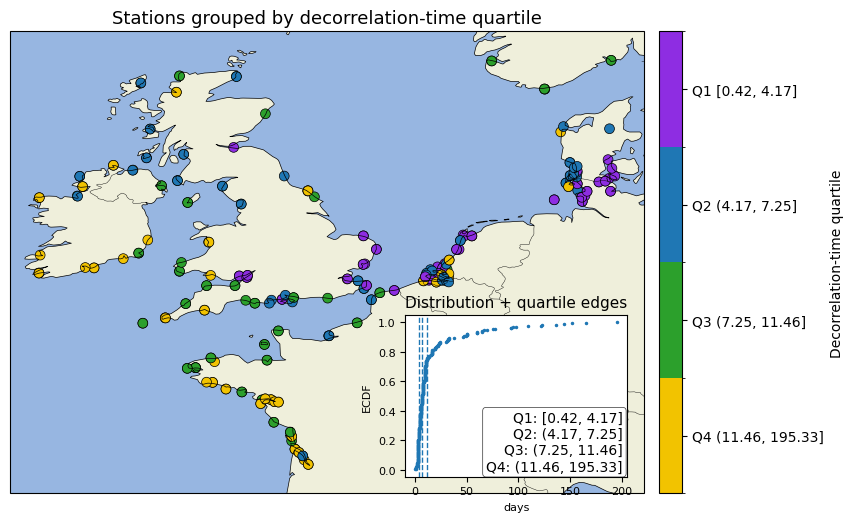

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# 1) Prepare data
plot_df = df.dropna(subset=["lat", "lon", "decorrelation_days"]).copy()
x = plot_df["decorrelation_days"].to_numpy()

# 2) Quartile edges (from the same data used for plotting)
q0, q25, q50, q75, q100 = np.quantile(x, [0, 0.25, 0.50, 0.75, 1.0])
print("Quartile edges (days):", {"0%": q0, "25%": q25, "50%": q50, "75%": q75, "100%": q100})

# Optional: labels that match the actual ranges
labels = [
    f"Q1 [{q0:.2f}, {q25:.2f}]",
    f"Q2 ({q25:.2f}, {q50:.2f}]",
    f"Q3 ({q50:.2f}, {q75:.2f}]",
    f"Q4 ({q75:.2f}, {q100:.2f}]",
]

plot_df["quartile"] = pd.qcut(plot_df["decorrelation_days"], q=4, labels=labels)
cat = plot_df["quartile"].astype("category")
plot_df["qcode"] = cat.cat.codes  # 0..3
base_cmap = plt.get_cmap("viridis")

# Very separated, viridis-like (purple/blue/green/yellow)
colors = ["#8E2DE2", "#1F77B4", "#2CA02C", "#F2C300"]  # purple, blue, green, yellow
cmap = mcolors.ListedColormap(colors)

norm = mcolors.BoundaryNorm(
    boundaries=[-0.5, 0.5, 1.5, 2.5, 3.5],
    ncolors=4
)
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, linewidth=0.2)
ax.add_feature(cfeature.OCEAN, linewidth=0.2)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)

sc = ax.scatter(
    plot_df["lon"].values,
    plot_df["lat"].values,
    c=plot_df["qcode"].values,
    s=50,
    edgecolors="black",
    linewidths=0.5,
    cmap=cmap,
    norm=norm,
    transform=ccrs.PlateCarree(),
)

cb = plt.colorbar(sc, ax=ax, pad=0.02, ticks=[0, 1, 2, 3])
cb.set_ticklabels(cat.cat.categories)
cb.set_label("Decorrelation-time quartile")
cb.ax.invert_yaxis()

# Extent around points
min_lon, max_lon = plot_df["lon"].min(), plot_df["lon"].max()
min_lat, max_lat = plot_df["lat"].min(), plot_df["lat"].max()
ax.set_extent([min_lon - 1, max_lon + 1, min_lat - 1, max_lat + 1], crs=ccrs.PlateCarree())
ax.set_title("Stations grouped by decorrelation-time quartile", fontsize=13)

# 4) Inset: ECDF in bottom-right
axins = inset_axes(ax, width="35%", height="35%", loc="lower right", borderpad=1.2)

xs = np.sort(x)
ecdf = np.arange(1, len(xs) + 1) / len(xs)
axins.plot(xs, ecdf, marker=".", linestyle="none", markersize=3)

# Quartile-edge lines
axins.axvline(q25, linestyle="--", linewidth=1)
axins.axvline(q50, linestyle="--", linewidth=1)
axins.axvline(q75, linestyle="--", linewidth=1)

# Show quartile ranges as text inside inset (top-left of inset)
txt = (
    f"Q1: [{q0:.2f}, {q25:.2f}]\n"
    f"Q2: ({q25:.2f}, {q50:.2f}]\n"
    f"Q3: ({q50:.2f}, {q75:.2f}]\n"
    f"Q4: ({q75:.2f}, {q100:.2f}]"
)
axins.text(
    0.98, 0.02,        # ← position (x, y)
    txt,
    transform=axins.transAxes,
    ha="right",        # ← anchor text to the right
    va="bottom",       # ← anchor text to the bottom
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.8, linewidth=0.5)
)

axins.set_xlabel("days", fontsize=8)
axins.set_ylabel("ECDF", fontsize=8)
axins.tick_params(axis="both", labelsize=8)
axins.set_title("Distribution + quartile edges", fontsize=11)

plt.show()

Quartile edges (days): {'0%': 0.4166666666666667, '25%': 4.166666666666667, '50%': 7.25, '75%': 11.458333333333334, '100%': 195.33333333333334}


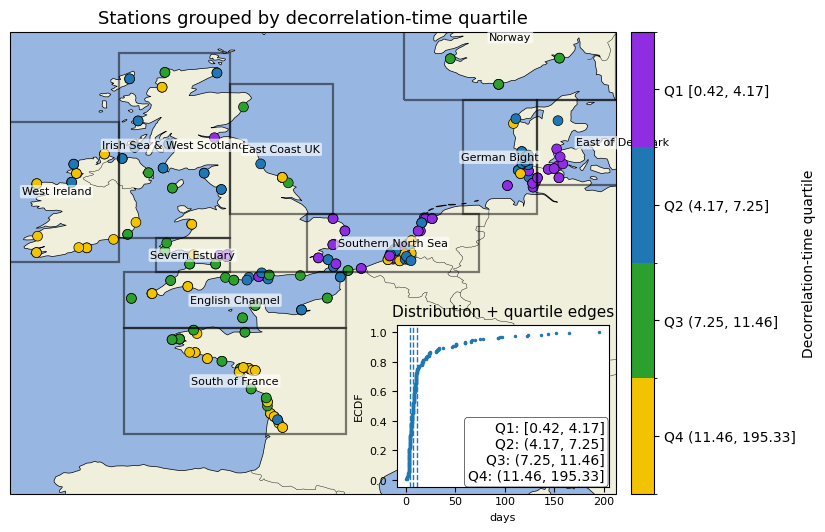

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

basin_boxes = {
    "West Ireland":               (-11.5,  -6.8, 51.3, 56.6),
    "Irish Sea & West Scotland":  ( -6.8,  -2.6, 52.2, 59.2),
    "Severn Estuary":             ( -5.4,  -2.6, 50.9, 52.2),
    "English Channel":            ( -6.6,   1.8, 48.8, 50.9),
    "East Coast UK":              ( -2.6,   1.3, 53.1, 58.0),
    "Southern North Sea":         (  0.3,   6.8, 50.9, 53.1),
    "German Bight":               (  6.2,   9, 53.1, 57.4),
    "East of Denmark":            (  9,  15.5, 54.2, 57.4),
    "Norway":                     (  4.0,  12.0, 57.4, 62.2),
    "South of France":            ( -6.6,   1.8, 44.8, 48.8),
}

def draw_basin_boxes(ax, basin_boxes, lw=1.6, zorder=10):
    for name, (lon0, lon1, lat0, lat1) in basin_boxes.items():
        rect = mpatches.Rectangle(
            (lon0, lat0),
            lon1 - lon0,
            lat1 - lat0,
            transform=ccrs.PlateCarree(),
            fill=False,                 # outline only
            linewidth=lw,
            edgecolor="black",
            zorder=zorder,
            alpha=0.5,
        )
        ax.add_patch(rect)

        ax.text(
            (lon0 + lon1) / 2,
            (lat0 + lat1) / 2,
            name,
            transform=ccrs.PlateCarree(),
            ha="center",
            va="center",
            fontsize=8,
            zorder=zorder + 1,
            bbox=dict(boxstyle="round,pad=0.15", facecolor="white", alpha=0.65, linewidth=0),
        )

# ----------------------------
# 1) Prepare data
# ----------------------------
plot_df = df.dropna(subset=["lat", "lon", "decorrelation_days"]).copy()
x = plot_df["decorrelation_days"].to_numpy()

# ----------------------------
# 2) Quartile edges
# ----------------------------
q0, q25, q50, q75, q100 = np.quantile(x, [0, 0.25, 0.50, 0.75, 1.0])
print("Quartile edges (days):", {"0%": q0, "25%": q25, "50%": q50, "75%": q75, "100%": q100})

labels = [
    f"Q1 [{q0:.2f}, {q25:.2f}]",
    f"Q2 ({q25:.2f}, {q50:.2f}]",
    f"Q3 ({q50:.2f}, {q75:.2f}]",
    f"Q4 ({q75:.2f}, {q100:.2f}]",
]

plot_df["quartile"] = pd.qcut(plot_df["decorrelation_days"], q=4, labels=labels)
cat = plot_df["quartile"].astype("category")
plot_df["qcode"] = cat.cat.codes  # 0..3

# Separated categorical colors
colors = ["#8E2DE2", "#1F77B4", "#2CA02C", "#F2C300"] 
cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], ncolors=4)

# ----------------------------
# 3) Map
# ----------------------------
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, linewidth=0.2)
ax.add_feature(cfeature.OCEAN, linewidth=0.2)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)

sc = ax.scatter(
    plot_df["lon"].values,
    plot_df["lat"].values,
    c=plot_df["qcode"].values,
    s=50,
    edgecolors="black",
    linewidths=0.5,
    cmap=cmap,
    norm=norm,
    transform=ccrs.PlateCarree(),
    zorder=5,
)

cb = plt.colorbar(sc, ax=ax, pad=0.02, ticks=[0, 1, 2, 3])
cb.set_ticklabels(cat.cat.categories)
cb.set_label("Decorrelation-time quartile")
cb.ax.invert_yaxis()

# Extent around points
min_lon, max_lon = plot_df["lon"].min(), plot_df["lon"].max()
min_lat, max_lat = plot_df["lat"].min(), plot_df["lat"].max()
ax.set_extent([min_lon - 1, max_lon + 2, min_lat - 2.5, max_lat + 1], crs=ccrs.PlateCarree())
ax.set_title("Stations grouped by decorrelation-time quartile", fontsize=13)

draw_basin_boxes(ax, basin_boxes, lw=1.6, zorder=10)

# ----------------------------
# 4) Inset ECDF
# ----------------------------
axins = inset_axes(ax, width="35%", height="35%", loc="lower right", borderpad=0.5)

xs = np.sort(x)
ecdf = np.arange(1, len(xs) + 1) / len(xs)
axins.plot(xs, ecdf, marker=".", linestyle="none", markersize=3, color="#1F77B4")

axins.axvline(q25, linestyle="--", linewidth=1, color="#1F77B4")
axins.axvline(q50, linestyle="--", linewidth=1, color="#1F77B4")
axins.axvline(q75, linestyle="--", linewidth=1, color="#1F77B4")

txt = (
    f"Q1: [{q0:.2f}, {q25:.2f}]\n"
    f"Q2: ({q25:.2f}, {q50:.2f}]\n"
    f"Q3: ({q50:.2f}, {q75:.2f}]\n"
    f"Q4: ({q75:.2f}, {q100:.2f}]"
)
axins.text(
    0.98, 0.02,
    txt,
    transform=axins.transAxes,
    ha="right",
    va="bottom",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.8, linewidth=0.5),
)

axins.set_xlabel("days", fontsize=8)
axins.set_ylabel("ECDF", fontsize=8)
axins.tick_params(axis="both", labelsize=8)
axins.set_title("Distribution + quartile edges", fontsize=11)

plt.show()

In [19]:
# Quartile boundaries (days)
q0, q25, q50, q75, q100 = plot_df["decorrelation_days"].quantile([0, .25, .5, .75, 1.0]).values

print("Quartile boundaries (days):")
print(f"Q0   (min)  = {q0:.2f}")
print(f"Q1 start    = {q0:.2f}   (bin: [{q0:.2f}, {q25:.2f}])")
print(f"Q2 start    = {q25:.2f}  (bin: ({q25:.2f}, {q50:.2f}])")
print(f"Q3 start    = {q50:.2f}  (bin: ({q50:.2f}, {q75:.2f}])")
print(f"Q4 start    = {q75:.2f}  (bin: ({q75:.2f}, {q100:.2f}])")
print(f"Q100 (max)  = {q100:.2f}")

Quartile boundaries (days):
Q0   (min)  = 0.42
Q1 start    = 0.42   (bin: [0.42, 4.17])
Q2 start    = 4.17  (bin: (4.17, 7.25])
Q3 start    = 7.25  (bin: (7.25, 11.46])
Q4 start    = 11.46  (bin: (11.46, 195.33])
Q100 (max)  = 195.33


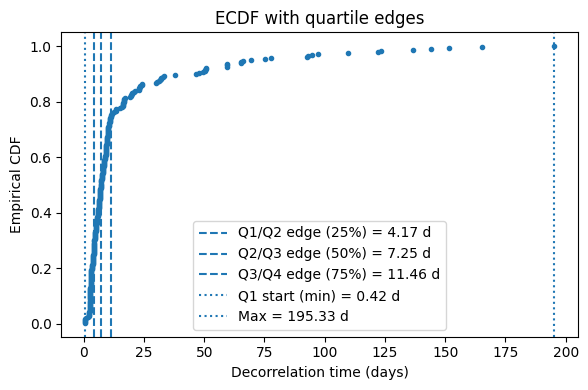

In [20]:
xs = np.sort(x)
ecdf = np.arange(1, len(xs) + 1) / len(xs)

# Quartile edges computed from the SAME data as ECDF
q0, q25, q50, q75, q100 = np.quantile(xs, [0, .25, .5, .75, 1.0])

plt.figure(figsize=(6, 4))
plt.plot(xs, ecdf, marker=".", linestyle="none")

# Plot quartile boundaries
plt.axvline(q25, linestyle="--", label=f"Q1/Q2 edge (25%) = {q25:.2f} d")
plt.axvline(q50, linestyle="--", label=f"Q2/Q3 edge (50%) = {q50:.2f} d")
plt.axvline(q75, linestyle="--", label=f"Q3/Q4 edge (75%) = {q75:.2f} d")

# Optional: show "beginnings" explicitly too (starts of bins)
plt.axvline(q0, linestyle=":",  label=f"Q1 start (min) = {q0:.2f} d")
plt.axvline(q100, linestyle=":", label=f"Max = {q100:.2f} d")

plt.xlabel("Decorrelation time (days)")
plt.ylabel("Empirical CDF")
plt.title("ECDF with quartile edges")
plt.legend()
plt.tight_layout()
plt.show()

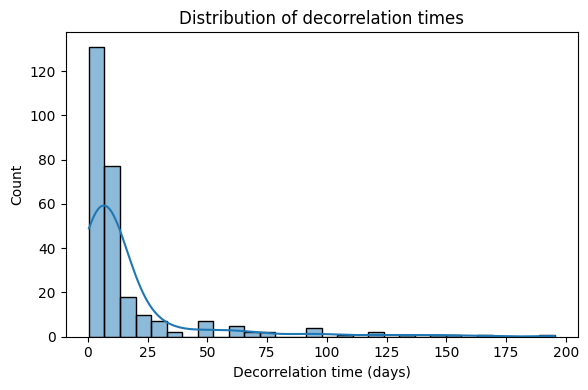

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.histplot(x, bins=30, kde=True)
plt.xlabel("Decorrelation time (days)")
plt.ylabel("Count")
plt.title("Distribution of decorrelation times")
plt.tight_layout()
plt.show()


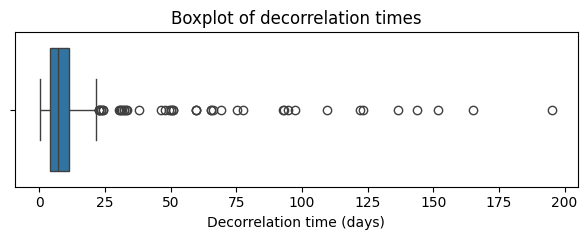

In [12]:
plt.figure(figsize=(6, 2.5))
sns.boxplot(x=x, orient="h")
plt.xlabel("Decorrelation time (days)")
plt.title("Boxplot of decorrelation times")
plt.tight_layout()
plt.show()


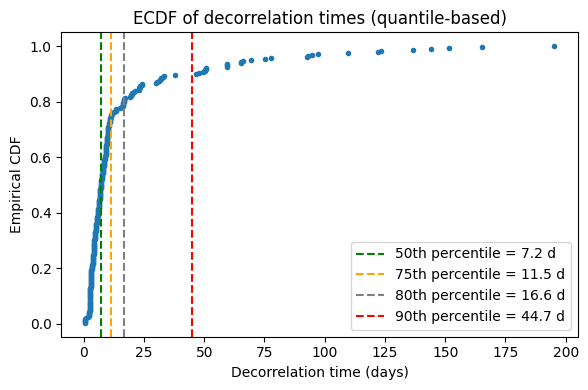

In [13]:
xs = np.sort(x)
ecdf = np.arange(1, len(xs) + 1) / len(xs)

# Quantiles
q50 = np.quantile(xs, 0.50)
q75 = np.quantile(xs, 0.75)
q80 = np.quantile(xs, 0.80)
q90 = np.quantile(xs, 0.90)

plt.figure(figsize=(6, 4))
plt.plot(xs, ecdf, marker=".", linestyle="none")

plt.axvline(q50, color="green", linestyle="--", label=f"50th percentile = {q50:.1f} d")
plt.axvline(q75, color="orange", linestyle="--", label=f"75th percentile = {q75:.1f} d")
plt.axvline(q80, color="grey", linestyle="--", label=f"80th percentile = {q80:.1f} d")
plt.axvline(q90, color="red", linestyle="--", label=f"90th percentile = {q90:.1f} d")

plt.xlabel("Decorrelation time (days)")
plt.ylabel("Empirical CDF")
plt.title("ECDF of decorrelation times (quantile-based)")
plt.legend()
plt.tight_layout()
plt.show()


~50% of stations decorrelate within ≈7–10 days

~75–80% of stations decorrelate within ≈15–20 days

~90% of stations decorrelate within ≈30 days

In [14]:
basin_boxes = {
    # lon_min, lon_max, lat_min, lat_max

    # West Ireland (keep separate)
    "West Ireland":           (-11.5,  -6.2, 51.3, 56.6),

    # Expanded: Irish Sea + West Scotland + extend east into north/east Scotland
    # Covers Irish Sea, Inner/Outer Hebrides, Minch, and across to Moray Firth-ish
    "Irish Sea & West Scotland": ( -6.8,   -1, 53.0, 59.2),

    # Severn / Bristol Channel (keep tight)
    "Severn Estuary":         ( -5.4,  -2.6, 50.0, 52.2),

    # English Channel (keep below ~51N to avoid collisions)
    "English Channel":        ( -6.6,   1.8, 48.8, 50.9),

    # East Coast UK (southern/central east coast; exclude the new Scotland extension by lat cap)
    "East Coast UK":          ( -2.2,   1.3, 51.2, 58),

    # Southern North Sea (east of UK into NL/BE; start east of ~1.3E)
    "Southern North Sea":     ( 0.3,   6.8, 51.0, 55.8),

    "German Bight":           (  6.2,   9.6, 53.1, 56.0),
    "East of Denmark":        (  8.5,  15.5, 54.2, 58.8),

    # Norway (trim to your map extent; adjust north if needed)
    "Norway":                 (  4.0,  12.0, 57.4, 62.2),

    "South of France":        ( -6.6,   1.8, 44.8, 48.9),
}



def draw_basin_boxes(ax, basin_boxes, alpha=0.12, lw=1.5):
    for name, (lon0, lon1, lat0, lat1) in basin_boxes.items():
        rect = mpatches.Rectangle(
            (lon0, lat0),
            lon1 - lon0,
            lat1 - lat0,
            transform=ccrs.PlateCarree(),
            fill=True,
            alpha=alpha,
            linewidth=lw,
            edgecolor="black",
            facecolor="none",  # keep transparent interior; change to e.g. "black" if you want shading
            zorder=3,
        )
        ax.add_patch(rect)

        # Label in the center of the box
        ax.text(
            (lon0 + lon1) / 2,
            (lat0 + lat1) / 2,
            name,
            transform=ccrs.PlateCarree(),
            ha="center",
            va="center",
            fontsize=8,
            zorder=4,
        )

In [62]:
basin_boxes = {
    "West Ireland":               (-11.5,  -6.8, 51.3, 56.6),
    "Irish Sea & West Scotland":  ( -6.8,  -2.6, 52.2, 59.2),
    "Severn Estuary":             ( -5.4,  -2.6, 50.9, 52.2),
    "English Channel":            ( -6.6,   1.8, 48.8, 50.9),
    "East Coast UK":              ( -2.6,   1.3, 53.1, 58.0),
    "Southern North Sea":         (  0.3,   6.8, 50.9, 53.1),
    "German Bight":               (  6.2,   9, 53.1, 57.4),
    "East of Denmark":            (  9,  15.5, 54.2, 57.4),
    "Norway":                     (  4.0,  12.0, 57.4, 62.2),
    "South of France":            ( -6.6,   1.8, 44.8, 48.8),
}


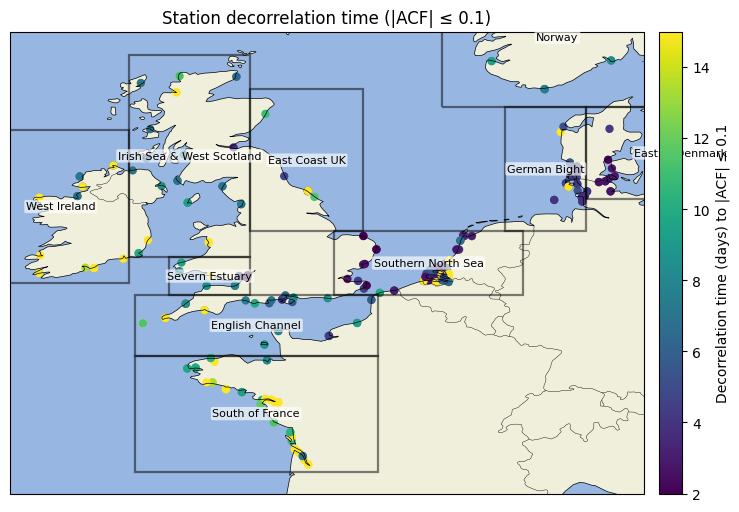

In [63]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Keep only rows with valid coordinates and tau
plot_df = df.dropna(subset=["lat", "lon", "decorrelation_days"]).copy()

fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, linewidth=0.2)
ax.add_feature(cfeature.OCEAN, linewidth=0.2)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)

sc = ax.scatter(
    plot_df["lon"].values,
    plot_df["lat"].values,
    c=plot_df["decorrelation_days"].values,
    s=25,
    vmin=2,
    vmax=15,
    transform=ccrs.PlateCarree(),
)


cb = plt.colorbar(sc, ax=ax, orientation="vertical", pad=0.02)
cb.set_label("Decorrelation time (days) to |ACF| ≤ 0.1")

# Reasonable map extent around points
min_lon, max_lon = plot_df["lon"].min(), plot_df["lon"].max()
min_lat, max_lat = plot_df["lat"].min(), plot_df["lat"].max()
ax.set_extent([min_lon - 1, max_lon + 1, min_lat - 1, max_lat + 1], crs=ccrs.PlateCarree())
draw_basin_boxes(ax, basin_boxes)
ax.set_title("Station decorrelation time (|ACF| ≤ 0.1)")
plt.show()


In [64]:
import numpy as np
import pandas as pd

# Priority order (must match your basin_boxes keys)
basin_order = [
    "Severn Estuary",
    "English Channel",
    "West Ireland",
    "Irish Sea & West Scotland",
    "Southern North Sea",
    "East Coast UK",
    "German Bight",
    "East of Denmark",
    "Norway",
    "South of France",
]

def assign_basin_from_boxes(lat, lon, basin_boxes, basin_order):
    # normalize lon if needed
    if pd.isna(lat) or pd.isna(lon):
        return np.nan
    lon = float(lon)
    lat = float(lat)
    if lon > 180:
        lon -= 360

    for b in basin_order:
        lon0, lon1, lat0, lat1 = basin_boxes[b]
        if (lat0 <= lat <= lat1) and (lon0 <= lon <= lon1):
            return b
    return np.nan

# Apply classification using basin_boxes
df2 = df.copy()
df2["basin"] = [
    assign_basin_from_boxes(lat, lon, basin_boxes, basin_order)
    for lat, lon in zip(df2["lat"], df2["lon"])
]

# Keep only classified rows with valid decorrelation
df_basin = df2.dropna(subset=["basin", "decorrelation_days"]).copy()

# Inspect unclassified stations (optional)
unclassified = df2[df2["basin"].isna()][["station", "lat", "lon", "decorrelation_days"]]
print("Unclassified stations:", len(unclassified))

# Basin-based summary table
basin_stats = (
    df_basin.groupby("basin")["decorrelation_days"]
    .agg(mean="mean", median="median", n="count", std="std")
    .reindex(basin_order)
    .reset_index()
)

basin_stats



Unclassified stations: 0


,basin,mean,median,n,std
0,Severn Estuary,14.758333,5.416667,15,25.839919
1,English Channel,11.358073,8.500000,32,13.243455
2,West Ireland,18.693627,15.083333,17,13.563788
3,Irish Sea & West Scotland,21.889323,8.750000,32,29.961130
4,Southern North Sea,14.627741,3.937500,76,33.695109
5,East Coast UK,9.523810,10.875000,7,5.656233
6,German Bight,6.175926,5.208333,27,5.844076
7,East of Denmark,3.076923,2.791667,13,0.870166
8,Norway,8.458333,8.250000,7,0.901067
9,South of France,31.273050,13.416667,47,38.016989


/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_32850/2492759061.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(plot_stats["basin"], rotation=30, ha="right")


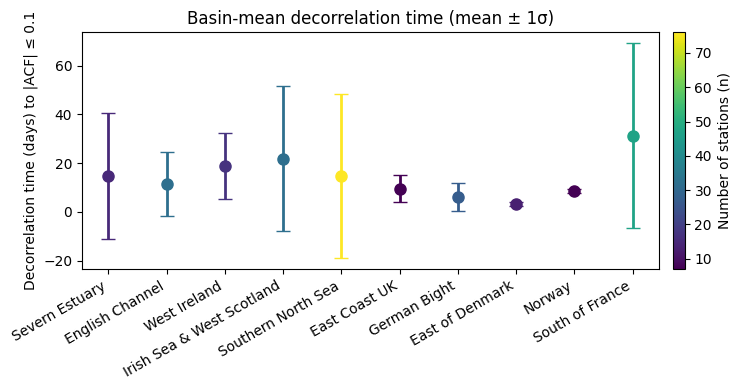

In [66]:
import matplotlib.pyplot as plt
import numpy as np

plot_stats = basin_stats.dropna(subset=["mean"]).copy()

# Use a perceptually uniform colormap
cmap = plt.cm.viridis
norm = plt.Normalize(plot_stats["n"].min(), plot_stats["n"].max())

fig, ax = plt.subplots(figsize=(8, 4))

for i, row in plot_stats.iterrows():
    ax.errorbar(
        row["basin"],
        row["mean"],
        yerr=row["std"],
        fmt="o",
        color=cmap(norm(row["n"])),
        capsize=5,
        markersize=8,
        linewidth=2,
    )

# Colorbar for sample size
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cb = plt.colorbar(sm, ax=ax, pad=0.02)
cb.set_label("Number of stations (n)")

ax.set_ylabel("Decorrelation time (days) to |ACF| ≤ 0.1")
ax.set_title("Basin-mean decorrelation time (mean ± 1σ)")
ax.set_xticklabels(plot_stats["basin"], rotation=30, ha="right")

plt.tight_layout()
plt.show()


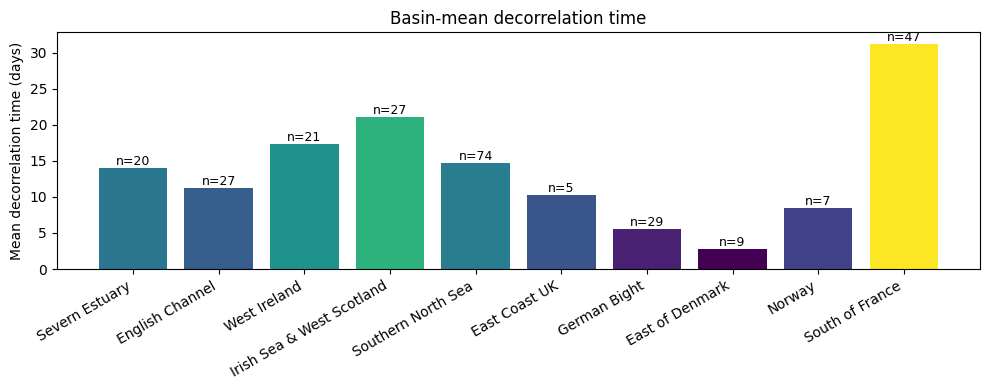

In [18]:
fig, ax = plt.subplots(figsize=(10, 4))

bars = ax.bar(
    plot_stats["basin"],
    plot_stats["mean"],
    color=plt.cm.viridis(
        (plot_stats["mean"] - plot_stats["mean"].min())
        / (plot_stats["mean"].max() - plot_stats["mean"].min())
    ),
)

ax.set_ylabel("Mean decorrelation time (days)")
ax.set_title("Basin-mean decorrelation time")

for bar, n in zip(bars, plot_stats["n"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"n={int(n)}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()
